In [46]:
import pandas as pd


# https://open.africa/dataset/ebola-case-figures-2026/resource/1f9c8fa3-7a9d-4323-aeda-30d22505a003
df = pd.read_csv('./drc_national_timeseries-national-2.csv')
df.head()

,Sitrep,Report_date,Publication_date,Provinces,Zones,Confirmed,Deaths,cfr_pct tasa mortalitat,in_isolation,Recovered,Unnamed: 10,Unnamed: 11,Unnamed: 12,Status
0,55,7/8/2026,7/9/2026,3.0,37.0,1792,625.0,34.9,764.0,295.0,NaN,NaN,NaN,provisional
1,56,7/9/2026,7/10/2026,3.0,37.0,1830,648.0,35.4,780.0,300.0,NaN,NaN,NaN,final
2,57,7/10/2026,7/11/2026,5.0,41.0,1873,672.0,35.9,763.0,306.0,NaN,NaN,NaN,provisional
3,58,7/11/2026,7/12/2026,5.0,42.0,1926,702.0,36.4,753.0,318.0,NaN,NaN,NaN,provisional
4,59,7/12/2026,7/13/2026,5.0,42.0,1963,719.0,36.6,736.0,333.0,NaN,NaN,NaN,final


In [47]:
df = df[['Sitrep', 'Report_date', 'Publication_date', 'Provinces', 'Zones',
       'Confirmed', 'Deaths', 'cfr_pct tasa mortalitat', 'in_isolation',
       'Recovered'
       ]]
df.head()

,Sitrep,Report_date,Publication_date,Provinces,Zones,Confirmed,Deaths,cfr_pct tasa mortalitat,in_isolation,Recovered
0,55,7/8/2026,7/9/2026,3.0,37.0,1792,625.0,34.9,764.0,295.0
1,56,7/9/2026,7/10/2026,3.0,37.0,1830,648.0,35.4,780.0,300.0
2,57,7/10/2026,7/11/2026,5.0,41.0,1873,672.0,35.9,763.0,306.0
3,58,7/11/2026,7/12/2026,5.0,42.0,1926,702.0,36.4,753.0,318.0
4,59,7/12/2026,7/13/2026,5.0,42.0,1963,719.0,36.6,736.0,333.0


Es tracta de dades reals no preparades, per tant el resultat pot no ser satisfactori. 

1. Detecta valors que falten i imputa amb scikit-learn amb la mitjana. Es tracta de predir les morts i els recuperats. 
2. Transforma les dates en una variable numèrica
3. Fes un anàlisi de correlacions per detectar variables massa correlacionades
4. Fer una regressió lineal normal i una regularizada. Compara els resultats. 



In [48]:
df['Provinces'] = df['Provinces'].fillna(df['Provinces'].mean())
df['Zones'] = df['Zones'].fillna(df['Zones'].mean())
df['Confirmed'] = df['Confirmed'].fillna(df['Confirmed'].mean())
df['Deaths'] = df['Deaths'].fillna(df['Deaths'].mean())
df['cfr_pct tasa mortalitat'] = df['cfr_pct tasa mortalitat'].fillna(df['cfr_pct tasa mortalitat'].mean())
df['in_isolation'] = df['in_isolation'].fillna(df['in_isolation'].mean())
df['Recovered'] = df['Recovered'].fillna(df['Recovered'].mean())
df['Report_date'] = pd.to_datetime(df['Report_date'], errors='coerce')
df['Data_consecutiva'] = df['Report_date'].rank(method='dense').astype(int)

df.describe()

,Sitrep,Report_date,Provinces,Zones,Confirmed,Deaths,cfr_pct tasa mortalitat,in_isolation,Recovered,Data_consecutiva
count,57.000000,57,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,90.087719,2026-08-12 02:06:18.947368,5.555556,53.320755,4600.245614,2126.254545,44.754545,773.464286,1005.553571,29.000000
min,55.000000,2026-07-08 00:00:00,3.000000,37.000000,1792.000000,625.000000,34.900000,570.000000,295.000000,1.000000
25%,69.000000,2026-07-22 00:00:00,5.000000,48.000000,2905.000000,1309.000000,43.900000,733.000000,540.000000,15.000000
50%,88.000000,2026-08-10 00:00:00,5.555556,53.320755,4449.000000,2126.254545,45.900000,764.000000,918.000000,29.000000
75%,111.000000,2026-09-02 00:00:00,6.000000,60.000000,6342.000000,3039.000000,48.200000,821.000000,1475.000000,43.000000
max,130.000000,2026-09-21 00:00:00,7.000000,63.000000,7773.000000,3759.000000,48.600000,930.000000,1935.000000,57.000000
std,23.195813,NaN,0.838082,7.245130,1941.520384,988.877181,4.121972,69.842671,514.109595,16.598193


In [49]:
df.head()

,Sitrep,Report_date,Publication_date,Provinces,Zones,Confirmed,Deaths,cfr_pct tasa mortalitat,in_isolation,Recovered,Data_consecutiva
0,55,2026-07-08,7/9/2026,3.0,37.0,1792,625.0,34.9,764.0,295.0,1
1,56,2026-07-09,7/10/2026,3.0,37.0,1830,648.0,35.4,780.0,300.0,2
2,57,2026-07-10,7/11/2026,5.0,41.0,1873,672.0,35.9,763.0,306.0,3
3,58,2026-07-11,7/12/2026,5.0,42.0,1926,702.0,36.4,753.0,318.0,4
4,59,2026-07-12,7/13/2026,5.0,42.0,1963,719.0,36.6,736.0,333.0,5


In [53]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X = df[['Provinces', 'Zones', 'Confirmed', 'cfr_pct tasa mortalitat', 'in_isolation', 'Recovered', 'Data_consecutiva']]

# 1. Seleccionem només les columnes que són de tipus float64
columnes_float = X.select_dtypes(include=['number']).columns

# 2. Inicialitzem l'StandardScaler i l'MinMaxScaler
scaler = StandardScaler()

# 3. Apliquem l'escalat a aquestes columnes i les tornem a assignar al DataFrame

X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X  # Estadístiques descriptives després de l'escalat


,Provinces,Zones,Confirmed,cfr_pct tasa mortalitat,in_isolation,Recovered,Data_consecutiva
0,-3.076397e+00,-2.272676,-1.459273,-2.411987e+00,-1.367132e-01,-1.394391,-1.701926
1,-3.076397e+00,-2.272676,-1.439527,-2.289608e+00,9.440949e-02,-1.384579,-1.641143
2,-6.687820e-01,-1.715673,-1.417182,-2.167228e+00,-1.511584e-01,-1.372804,-1.580360
3,-6.687820e-01,-1.576422,-1.389641,-2.044849e+00,-2.956100e-01,-1.349256,-1.519577
4,-6.687820e-01,-1.576422,-1.370415,-1.995897e+00,-5.411779e-01,-1.319820,-1.458794
5,-6.687820e-01,-1.158670,-1.345472,-1.775614e+00,-2.956100e-01,-1.255060,-1.398011
6,-6.687820e-01,-1.158670,-1.313255,-1.555331e+00,-5.267327e-01,-1.233474,-1.337227
7,-6.687820e-01,-1.019420,-1.286753,-1.408476e+00,-7.000747e-01,-1.207963,-1.276444
8,-6.687820e-01,0.000000,-1.257134,1.739116e-15,-1.642225e-15,0.000000,-1.215661
9,-6.687820e-01,-1.019420,-1.212445,-1.310572e+00,-7.434102e-01,-1.164790,-1.154878


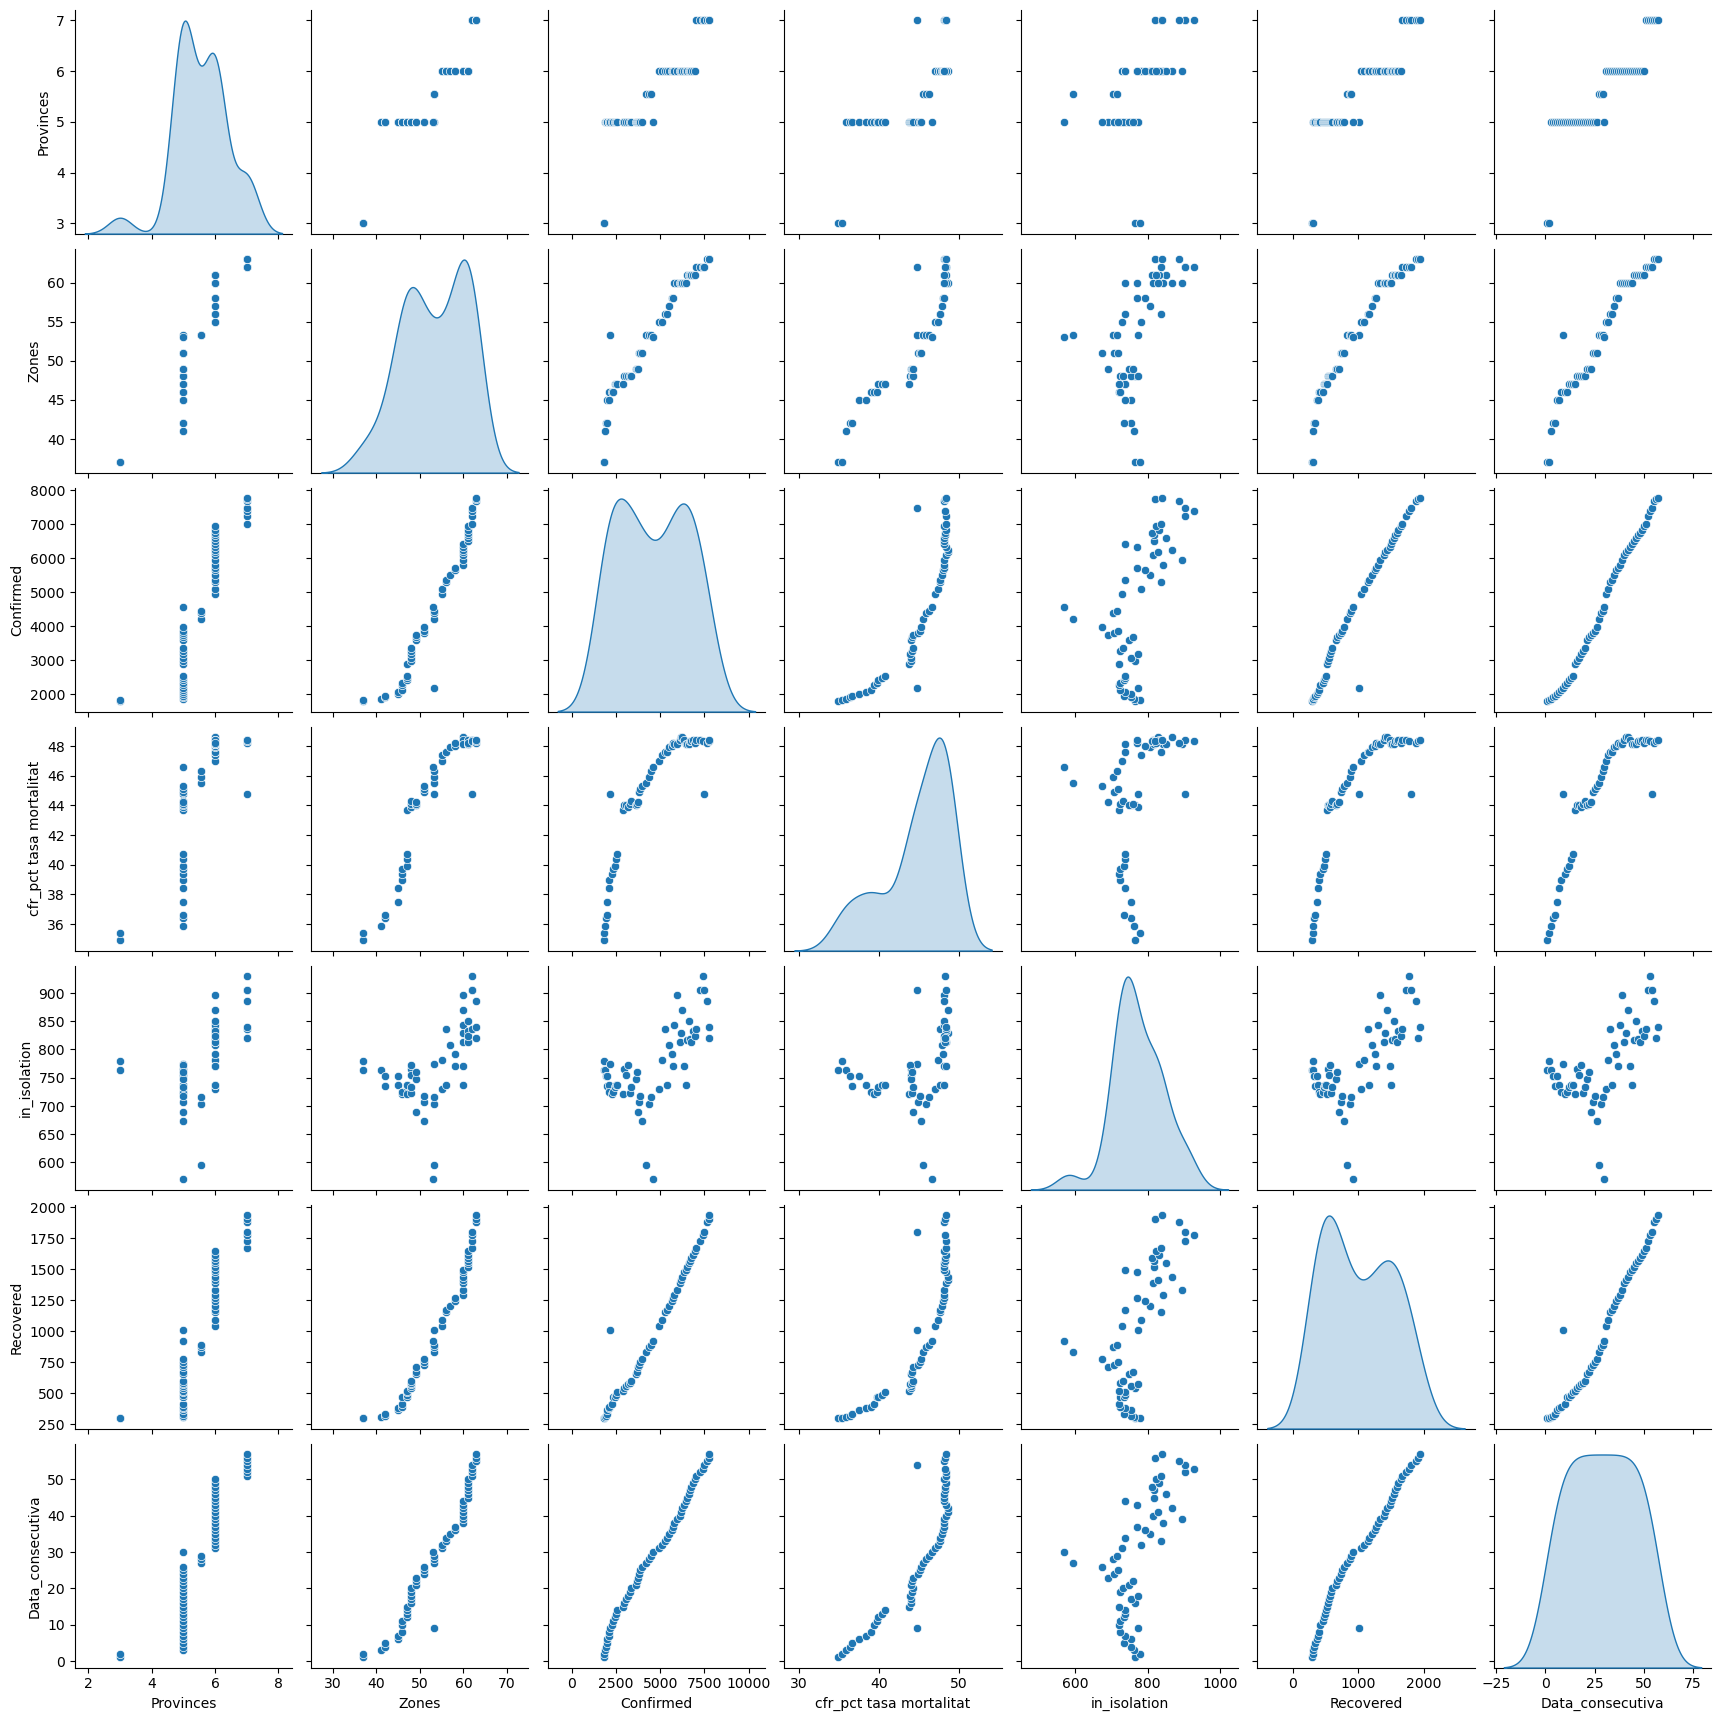

In [54]:
import seaborn as sns
sns.pairplot(data=df, vars=columnes_float, kind='scatter', diag_kind='kde')

<Axes: >

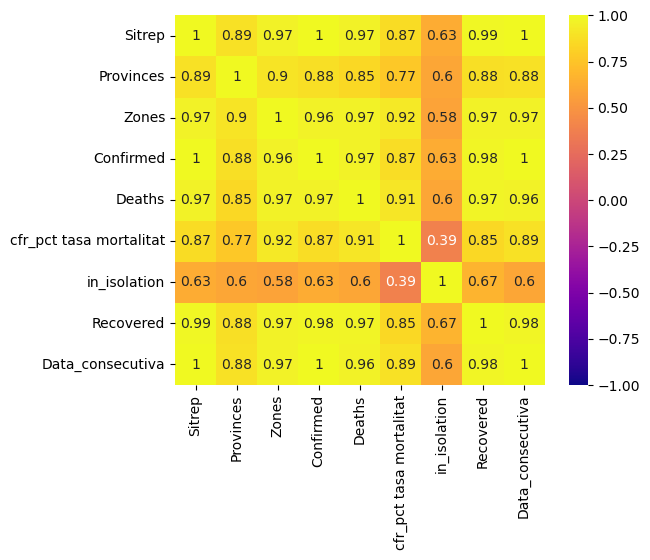

In [55]:
# 1. Separar columnes numèriques (incloses les dummies)
df_num = df.select_dtypes(include=['int64', 'float64', 'uint8'])

# 2. Calcular la correlació només sobre aquestes
corr_matrix = df_num.corr()

# 3. Dibuixar el heatmap
sns.heatmap(corr_matrix, square=True, annot=True, vmin=-1, vmax=1, cmap='plasma')

In [56]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit(X,df["Deaths"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ -12.4 ,-208. , 519.57,..., -21.5 , 926.21,-621.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Provinces','Zones','Confirmed',...,'in_isolation','Recovered', 'Data_consecutiva']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2126
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7


In [57]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

y_pred = reg.predict(X)

    # Calcular mètriques de rendiment
mse = mean_squared_error(df["Deaths"], y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(df["Deaths"], y_pred)
mae = mean_absolute_error(df["Deaths"], y_pred)
mape = mean_absolute_percentage_error(df["Deaths"], y_pred)
#rmsle = root_mean_squared_log_error(y_test,y_pred)

print("MSE",mse)
print("RMSE",rmse)
print("R²",r2)
print("MAE",mae)
print("MAPE",mape)
#print("RMSLE",rmsle)

intercept = reg.intercept_
coefficients = reg.coef_
print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("Feature names:", X.columns)
print("Model equation: Deaths =", intercept, "+", " + ".join(f"{coef}*{name}" for coef, name in zip(coefficients, X.columns)))

MSE 22041.48782582713
RMSE 148.463759301141
R² 0.9770573793405879
MAE 78.62995042842083
MAPE 0.04478631035646358
Intercept: 2126.254545454546
Coefficients: [ -12.40128909 -207.99512638  519.57363739  413.3726941   -21.50483978
  926.20850488 -621.00993586]
Feature names: Index(['Provinces', 'Zones', 'Confirmed', 'cfr_pct tasa mortalitat',
       'in_isolation', 'Recovered', 'Data_consecutiva'],
      dtype='str')
Model equation: Deaths = 2126.254545454546 + -12.401289086369589*Provinces + -207.9951263803274*Zones + 519.5736373924019*Confirmed + 413.3726940957538*cfr_pct tasa mortalitat + -21.50483977765783*in_isolation + 926.2085048823689*Recovered + -621.0099358618324*Data_consecutiva


In [58]:
from sklearn.linear_model import ElasticNet

# Crear un model ElasticNet
reg = ElasticNet(alpha=0.1, l1_ratio=0.5)

# Entrenar el model
reg.fit(X, df["Deaths"])


,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [59]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

y_pred = reg.predict(X)

    # Calcular mètriques de rendiment
mse = mean_squared_error(df["Deaths"], y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(df["Deaths"], y_pred)
mae = mean_absolute_error(df["Deaths"], y_pred)
mape = mean_absolute_percentage_error(df["Deaths"], y_pred)
#rmsle = root_mean_squared_log_error(y_test,y_pred)

print("MSE",mse)
print("RMSE",rmse)
print("R²",r2)
print("MAE",mae)
print("MAPE",mape)
#print("RMSLE",rmsle)

intercept = reg.intercept_
coefficients = reg.coef_
print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("Feature names:", X.columns)
print("Model equation: Deaths =", intercept, "+", " + ".join(f"{coef}*{name}" for coef, name in zip(coefficients, X.columns)))

MSE 31316.34041378514
RMSE 176.96423484361222
R² 0.9674033384573698
MAE 98.7119679396292
MAPE 0.06305910486845077
Intercept: 2126.254545454546
Coefficients: [-48.99164764 151.357715   173.37497903 238.66755058  35.41625346
 352.64287861  85.34080665]
Feature names: Index(['Provinces', 'Zones', 'Confirmed', 'cfr_pct tasa mortalitat',
       'in_isolation', 'Recovered', 'Data_consecutiva'],
      dtype='str')
Model equation: Deaths = 2126.254545454546 + -48.991647638393125*Provinces + 151.35771500241103*Zones + 173.37497903322577*Confirmed + 238.6675505773353*cfr_pct tasa mortalitat + 35.416253463819466*in_isolation + 352.64287860765694*Recovered + 85.34080665265616*Data_consecutiva
